# GeoPandas Beginner Exercises

In [1]:
# Imports
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## When to Use Which CRS

### 🌍 Global map (visual only)
Use:
EPSG:4326
(WGS84 – longitude/latitude)

---

### 📏 Distance and Area in Europe
Use:
EPSG:3035
(ETRS89 / LAEA Europe – meters)

---

### 🗽 Distance / area in USA
Use:
EPSG:32618
(UTM zone 18N – meters)

---

### 🇧🇪 Distance / area in Belgium
Use:
EPSG:31370
(Belgian Lambert 72 – meters)

---

### 🇳🇱 Distance / area in Netherlands
Use:
EPSG:28992
(Amersfoort / RD New – meters)

---

## Rule

If you compute:
- distance
- area
- buffer

→ use a projected CRS in meters.

If you only plot a world map
→ EPSG:4326 is fine.


In [2]:
# Load dataset (GeoPandas built-in)
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url).rename({"ADMIN": "name"}, axis="columns")

world.head()

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,name,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,None,None,None,None,None,None,None,None,None,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,Unrecognized,Unrecognized,None,None,Unrecognized,None,None,None,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,1,Canada,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,Admin-0 country,1,2,United States of America,US1,1,2,Country,1,United States of America,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."


## Exercise 1 — Inspect structure
Show: number of rows, columns, dtypes, CRS,...

rows: 177


cols: 169


CRS: EPSG:4326


featurecla      object
scalerank        int32
LABELRANK        int32
SOVEREIGNT      object
SOV_A3          object
                ...   
FCLASS_NL       object
FCLASS_SE       object
FCLASS_BD       object
FCLASS_UA       object
geometry      geometry
Length: 169, dtype: object

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,name,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,None,None,None,None,None,None,None,None,None,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,Unrecognized,Unrecognized,None,None,Unrecognized,None,None,None,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,1,Canada,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,Admin-0 country,1,2,United States of America,US1,1,2,Country,1,United States of America,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."


featurecla                                      Admin-0 country
scalerank                                                     1
LABELRANK                                                     6
SOVEREIGNT                                                 Fiji
SOV_A3                                                      FJI
                                    ...                        
FCLASS_NL                                                  None
FCLASS_SE                                                  None
FCLASS_BD                                                  None
FCLASS_UA                                                  None
geometry      MULTIPOLYGON (((180 -16.067132663642447, 180 -...
Name: 0, Length: 169, dtype: object

## Exercise 2 — Basic map
Plot the world map with country boundaries visible.

Text(0.5, 1.0, 'Natural Earth')

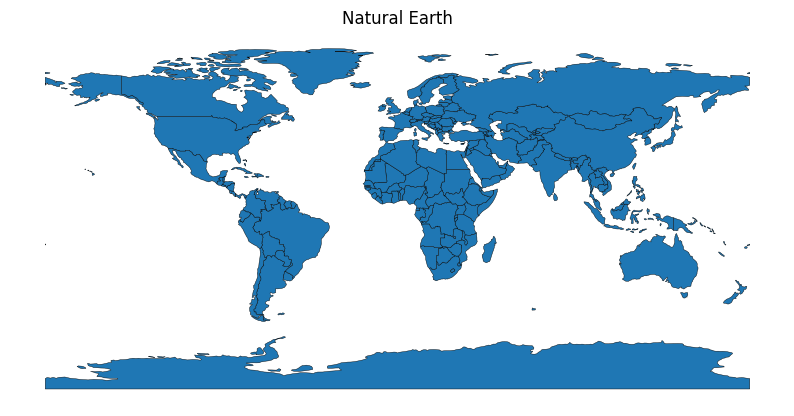

## Exercise 3 — Filter to Europe
Create a GeoDataFrame `eu` with only European countries and plot it.

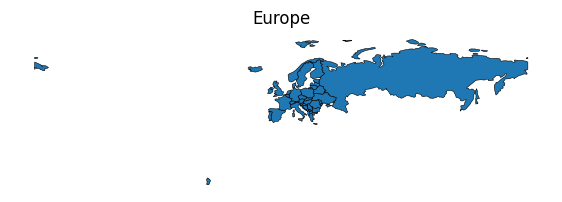

,name,CONTINENT,POP_EST
18,Russia,Europe,144373535.0
21,Norway,Europe,5347896.0
43,France,Europe,67059887.0
110,Sweden,Europe,10285453.0
111,Belarus,Europe,9466856.0


## Exercise 4 — Add a derived column
Add `pop_millions` and show the 10 most populous countries (name + pop_millions).

,name,pop_millions
139,China,1397.715000
98,India,1366.417754
4,United States of America,328.239523
8,Indonesia,270.625568
102,Pakistan,216.565318
29,Brazil,211.049527
56,Nigeria,200.963599
99,Bangladesh,163.046161
18,Russia,144.373535
27,Mexico,127.575529


## Exercise 5 — A choropleth
Make a choropleth of `pop_millions`.
Constraint: missing values should not break the plot.

Text(0.5, 1.0, 'Population (millions)')

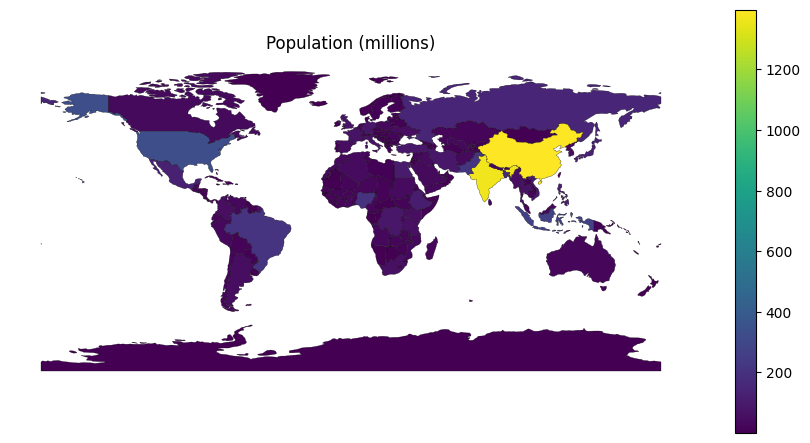

## Exercise 6 — Areas (km²)
Compute area in km² for European countries and list the 10 largest by area.
Constraint: compute area in EPSG:3035.

,name,area_km2
18,Russia,1.701671e+07
43,France,6.448534e+05
112,Ukraine,5.725399e+05
132,Spain,5.023083e+05
110,Sweden,4.505641e+05
21,Norway,3.979478e+05
121,Germany,3.574253e+05
151,Finland,3.412330e+05
141,Italy,3.150991e+05
113,Poland,3.103969e+05


## Exercise 7 — Distance to Brussels (km)
You are given `brussels` (Brussels point in EPSG:3035).
Compute each European country's centroid distance to Brussels in km and return the 10 closest countries.

Given:
- `eu` has CRS EPSG:3035
- `brussels` has CRS EPSG:3035


,name,distance_km
129,Belgium,27.544606
128,Luxembourg,166.717313
130,Netherlands,179.267941
121,Germany,416.403104
127,Switzerland,529.095981
143,United Kingdom,584.841326
142,Denmark,686.020972
153,Czechia,791.013019
114,Austria,792.158864
133,Ireland,884.639563


## Exercise 8 — Spatial predicate
Which European countries contain Brussels? (Should be exactly one.)

129    Belgium
Name: name, dtype: object